In [130]:
!pip install fastapi uvicorn python-multipart

In [131]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [132]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == "document_classifier.keras":
            print(os.path.join(root, file))

/content/drive/MyDrive/document_classifier.keras


In [133]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/document_classifier.keras"

model = load_model(model_path)

print("Model Loaded Successfully ✅")

Model Loaded Successfully ✅


In [134]:
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from tensorflow.keras.preprocessing import image
import numpy as np
import shutil

app = FastAPI()

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

class_names = [
    'handwritten',
    'specification',
    'email',
    'news article',
    'form',
    'scientific publication',
    'questionnaire',
    'presentation',
    'memo',
    'budget',
    'advertisement',
    'scientific report',
    'letter',
    'invoice',
    'resume',
    'file folder'
]


@app.get("/")
def home():
    return {"message": "Document Classification API Running"}


@app.post("/predict")
async def predict(file: UploadFile = File(...)):

    file_path = "uploaded_file.jpg"

    with open(file_path, "wb") as buffer:
        shutil.copyfileobj(file.file, buffer)

    img = image.load_img(
        file_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    result = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction)*100)

    return {
        "prediction": result,
        "confidence": confidence
    }

print("API Code Ready ✅")

API Code Ready ✅


In [135]:
!pip install nest_asyncio pyngrok

In [136]:
%%writefile main.py

from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def home():
    return {"message":"Document Classification API Running"}

Overwriting main.py


In [137]:
!uvicorn main:app --host 0.0.0.0 --port 8000 &

INFO:     Started server process [16946]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [138]:
!ls

drive		      main.py	 __pycache__  server.log
fee_receipt_test.jpg  nohup.out  sample_data  upload.jpg


In [139]:
!nohup uvicorn main:app --host 0.0.0.0 --port 8000 &

nohup: appending output to 'nohup.out'


In [140]:
import requests

response = requests.get("http://127.0.0.1:8000")
print(response.json())

{'message': 'Document Classification API Running'}


In [141]:
%%writefile main.py

from fastapi import FastAPI, File, UploadFile
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import shutil

app = FastAPI()

model = load_model("/content/drive/MyDrive/document_classifier.keras")

class_names = [
    'handwritten',
    'specification',
    'email',
    'news article',
    'form',
    'scientific publication',
    'questionnaire',
    'presentation',
    'memo',
    'budget',
    'advertisement',
    'scientific report',
    'letter',
    'invoice',
    'resume',
    'file folder'
]


@app.get("/")
def home():
    return {"message":"Document Classification API Running"}


@app.post("/predict")
async def predict(file: UploadFile = File(...)):

    file_path = "upload.jpg"

    with open(file_path,"wb") as buffer:
        shutil.copyfileobj(file.file, buffer)

    img = image.load_img(
        file_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)
    img_array = img_array/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    result = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction)*100)

    return {
        "prediction": result,
        "confidence": confidence
    }

Overwriting main.py


In [142]:
!pkill -f uvicorn

In [143]:
!nohup uvicorn main:app --host 0.0.0.0 --port 8000 &

nohup: appending output to 'nohup.out'


In [144]:
!apt-get update -y
!apt-get install -y poppler-utils

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.13).
0 upgraded, 0 newly install

In [145]:
!which pdfinfo

/usr/bin/pdfinfo


In [146]:
!pdfinfo -v

pdfinfo version 22.02.0
Copyright 2005-2022 The Poppler Developers - http://poppler.freedesktop.org
Copyright 1996-2011 Glyph & Cog, LLC


In [147]:
!pip install pymupdf

In [148]:
import fitz

pdf_path = "/content/drive/MyDrive/Feesrecipte.pdf"

doc = fitz.open(pdf_path)

page = doc[0]

pix = page.get_pixmap()

pix.save("/content/fee_receipt_test.jpg")

print("PDF converted to image ✅")

PDF converted to image ✅


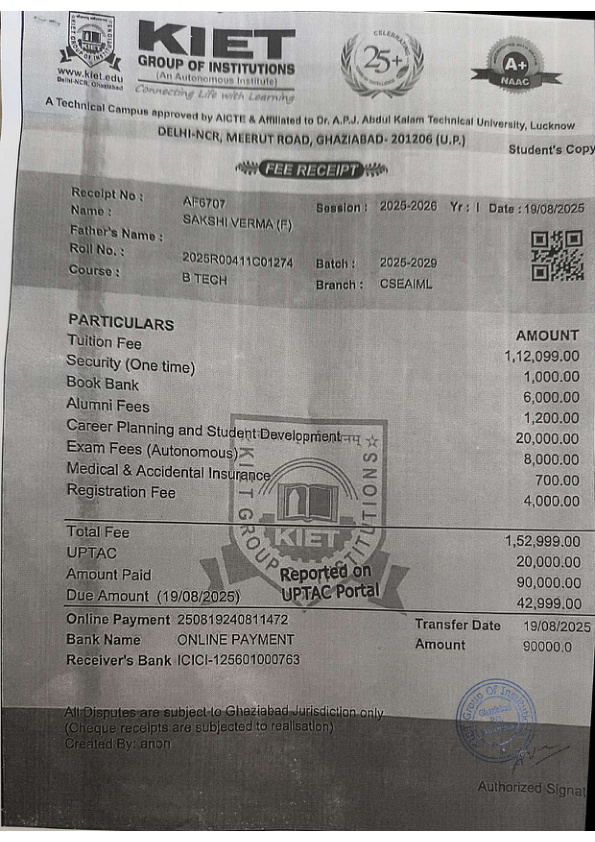

In [149]:
from PIL import Image

img = Image.open("/content/fee_receipt_test.jpg")
img

In [150]:
!pkill -f uvicorn

In [151]:
!nohup uvicorn main:app --host 0.0.0.0 --port 8000 > server.log 2>&1 &

In [152]:
import requests
import time

time.sleep(3)

try:
    r = requests.get("http://127.0.0.1:8000")
    print(r.status_code)
    print(r.json())
except Exception as e:
    print(e)

HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7e5db4642870>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [153]:
!cat server.log

In [154]:
!ps -ef | grep uvicorn

root       17754       1 62 15:24 ?        00:00:02 /usr/bin/python3 /usr/local/bin/uvicorn main:app --host 0.0.0.0 --port 8000
root       17788    1875  0 15:24 ?        00:00:00 /bin/bash -c ps -ef | grep uvicorn
root       17790   17788  0 15:24 ?        00:00:00 grep uvicorn


In [155]:
import requests

try:
    response = requests.get("http://127.0.0.1:8000/")
    print("Status Code:", response.status_code)
    print("Response:", response.text)
except Exception as e:
    print("Error:", e)

Error: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7e5db4642d80>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [156]:
!cat main.py


from fastapi import FastAPI, File, UploadFile
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import shutil

app = FastAPI()

model = load_model("/content/drive/MyDrive/document_classifier.keras")

class_names = [
    'handwritten',
    'specification',
    'email',
    'news article',
    'form',
    'scientific publication',
    'questionnaire',
    'presentation',
    'memo',
    'budget',
    'advertisement',
    'scientific report',
    'letter',
    'invoice',
    'resume',
    'file folder'
]


@app.get("/")
def home():
    return {"message":"Document Classification API Running"}


@app.post("/predict")
async def predict(file: UploadFile = File(...)):

    file_path = "upload.jpg"

    with open(file_path,"wb") as buffer:
        shutil.copyfileobj(file.file, buffer)

    img = image.load_img(
        file_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)
    img_array = img_arra

In [158]:
import requests

url = "http://127.0.0.1:8000/predict"

with open("/content/fee_receipt_test.jpg", "rb") as f:
    response = requests.post(url, files={"file": f})

print(response.status_code)
print(response.text)

200
{"prediction":"scientific report","confidence":19.928157806396484}
